In [ ]:
import pandas as pd

df = pd.read_csv("hate_speech_dataset.csv")

# remove useless column
df = df.drop(columns=["Unnamed: 0"])

print("Total tweets:", len(df))
print("Number of features:", df.shape[1])
print("Class distribution:\n", df["class"].value_counts())

Total tweets: 24783
Number of features: 2
Class distribution:
 class
1    19190
2     4163
0     1430
Name: count, dtype: int64


In [ ]:
df.head()

,class,tweet
0,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


In [ ]:
df["class"].value_counts()

,count
class,
1,19190
2,4163
0,1430


In [ ]:
df.isnull().sum()

,0
class,0
tweet,0


In [ ]:
duplicates = df.duplicated(subset="tweet").sum()
print("Duplicate tweets:", duplicates)

Duplicate tweets: 0


In [ ]:
for label in [0,1,2]:
    print("\nClass:", label)
    print(df[df["class"]==label]["tweet"].head(5))


Class: 0


NameError: name 'df' is not defined

# Data Cleaning

In [ ]:
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_tweet(text):

    # lowercase
    text = text.lower()

    # remove urls
    text = re.sub(r"http\S+", "", text)

    # remove mentions
    text = re.sub(r"@\w+", "", text)

    # remove hashtags
    text = re.sub(r"#\w+", "", text)

    # remove special characters
    text = re.sub(r"[^a-z\s]", "", text)

    # remove stopwords
    words = text.split()
    words = [w for w in words if w not in stop_words]

    # lemmatization
    words = [lemmatizer.lemmatize(w) for w in words]

    return " ".join(words)

In [ ]:
df["clean_tweet"] = df["tweet"].apply(clean_tweet)

In [ ]:
df = df.drop_duplicates(subset="clean_tweet")

In [ ]:
for i in range(5):
    print("Before:", df["tweet"].iloc[i])
    print("After :", df["clean_tweet"].iloc[i])
    print()

Before: !!! RT @mayasolovely: As a woman you shouldn't complain about cleaning up your house. &amp; as a man you should always take the trash out...
After : rt woman shouldnt complain cleaning house amp man always take trash

Before: !!!!! RT @mleew17: boy dats cold...tyga dwn bad for cuffin dat hoe in the 1st place!!
After : rt boy dat coldtyga dwn bad cuffin dat hoe st place

Before: !!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby4life: You ever fuck a bitch and she start to cry? You be confused as shit
After : rt dawg rt ever fuck bitch start cry confused shit

Before: !!!!!!!!! RT @C_G_Anderson: @viva_based she look like a tranny
After : rt look like tranny

Before: !!!!!!!!!!!!! RT @ShenikaRoberts: The shit you hear about me might be true or it might be faker than the bitch who told it to ya &#57361;
After : rt shit hear might true might faker bitch told ya



# Exploratory Data Analysis

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

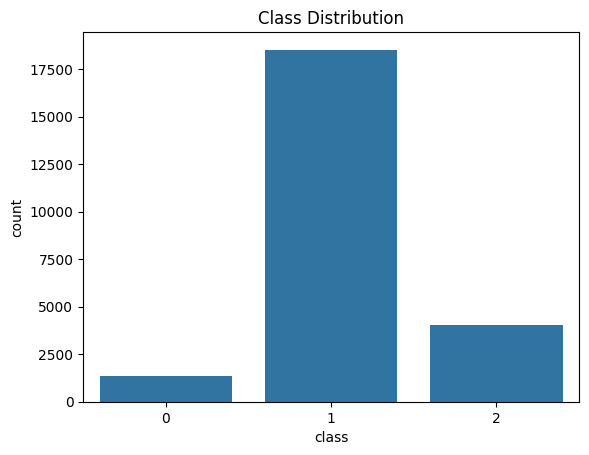

In [ ]:
sns.countplot(x="class", data=df)
plt.title("Class Distribution")
plt.show()

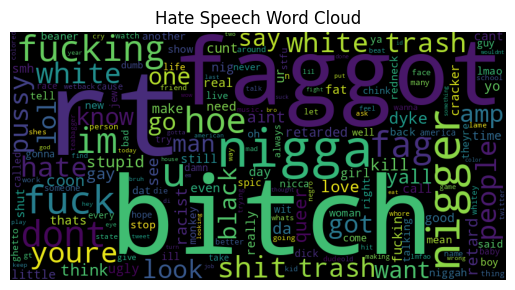

In [ ]:
hate_text = " ".join(df[df["class"]==0]["clean_tweet"])

wc = WordCloud(width=800, height=400).generate(hate_text)

plt.imshow(wc)
plt.axis("off")
plt.title("Hate Speech Word Cloud")
plt.show()

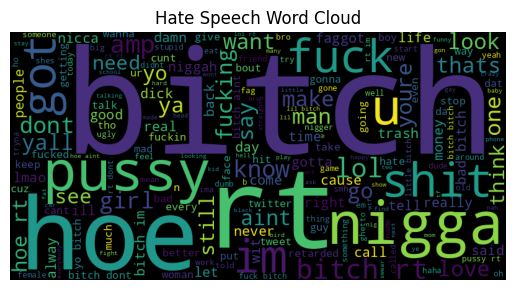

In [ ]:
hate_text = " ".join(df[df["class"]==1]["clean_tweet"])

wc = WordCloud(width=800, height=400).generate(hate_text)

plt.imshow(wc)
plt.axis("off")
plt.title("Hate Speech Word Cloud")
plt.show()

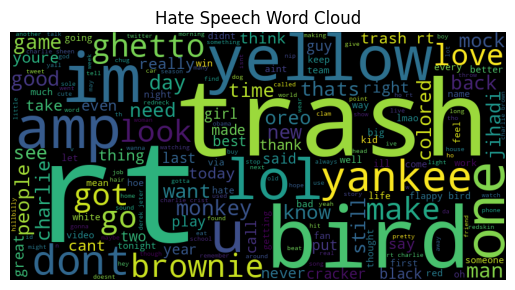

In [ ]:
hate_text = " ".join(df[df["class"]==2]["clean_tweet"])

wc = WordCloud(width=800, height=400).generate(hate_text)

plt.imshow(wc)
plt.axis("off")
plt.title("Hate Speech Word Cloud")
plt.show()

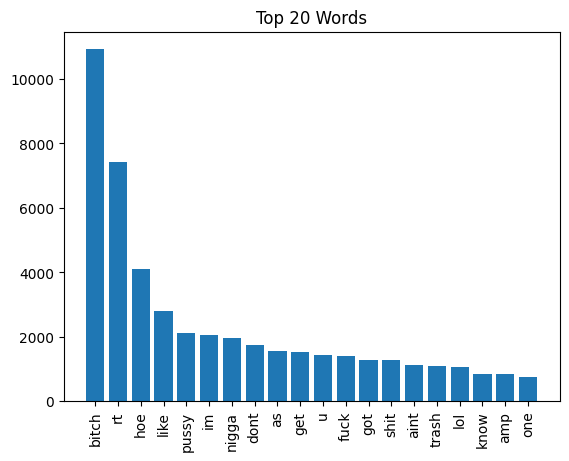

In [ ]:
from collections import Counter

all_words = " ".join(df["clean_tweet"]).split()

freq = Counter(all_words).most_common(20)

words, counts = zip(*freq)

plt.bar(words, counts)
plt.xticks(rotation=90)
plt.title("Top 20 Words")
plt.show()

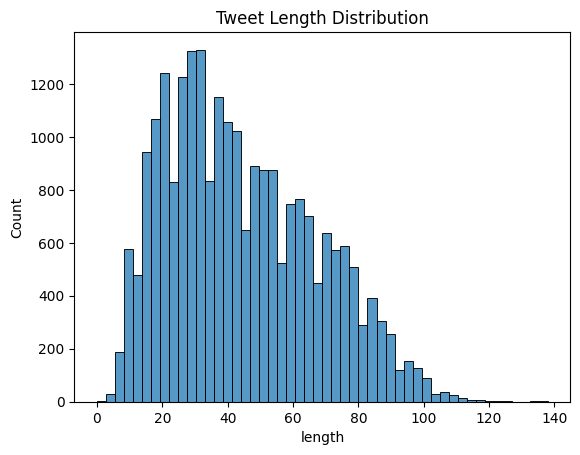

In [ ]:
df["length"] = df["clean_tweet"].apply(len)

sns.histplot(df["length"], bins=50)
plt.title("Tweet Length Distribution")
plt.show()

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

bow = CountVectorizer(max_features=5000)

X_bow = bow.fit_transform(df["clean_tweet"])
y = df["class"]

print("Vocabulary size:", len(bow.vocabulary_))
print("Feature matrix shape:", X_bow.shape)

Vocabulary size: 5000
Feature matrix shape: (23943, 5000)


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X_tfidf = tfidf.fit_transform(df["clean_tweet"])

print("Vocabulary size:", len(tfidf.vocabulary_))
print("Feature matrix:", X_tfidf.shape)

Vocabulary size: 5000
Feature matrix: (23943, 5000)


# Multi Class Classification

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

In [ ]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()

nb.fit(X_train, y_train)

pred_nb = nb.predict(X_test)

# Model Evaluation

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, pred_lr))
print(classification_report(y_test, pred_lr))

print("Naive Bayes")
print("Accuracy:", accuracy_score(y_test, pred_nb))
print(classification_report(y_test, pred_nb))

Logistic Regression
Accuracy: 0.9014408018375444
              precision    recall  f1-score   support

           0       0.68      0.19      0.29       269
           1       0.92      0.97      0.94      3687
           2       0.85      0.84      0.84       833

    accuracy                           0.90      4789
   macro avg       0.82      0.67      0.69      4789
weighted avg       0.89      0.90      0.89      4789

Naive Bayes
Accuracy: 0.8275214032157027
              precision    recall  f1-score   support

           0       0.50      0.00      0.01       269
           1       0.82      0.99      0.90      3687
           2       0.91      0.36      0.51       833

    accuracy                           0.83      4789
   macro avg       0.74      0.45      0.47      4789
weighted avg       0.82      0.83      0.78      4789



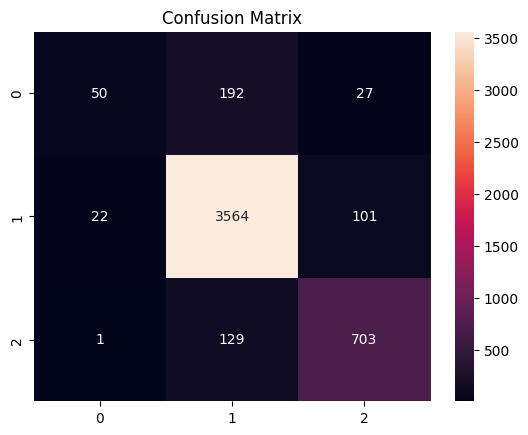

In [ ]:
cm = confusion_matrix(y_test, pred_lr)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()

# Resut Visualizations

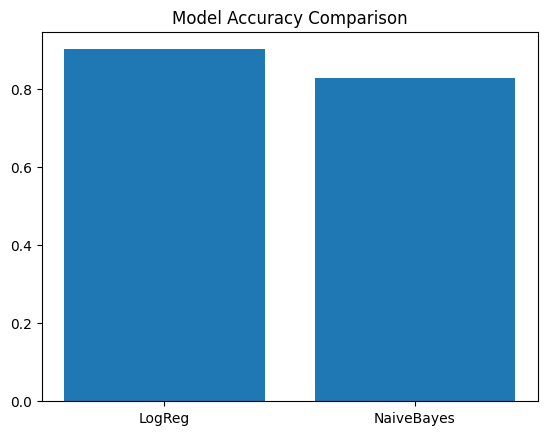

In [ ]:
acc_lr = accuracy_score(y_test, pred_lr)
acc_nb = accuracy_score(y_test, pred_nb)

plt.bar(["LogReg","NaiveBayes"], [acc_lr, acc_nb])
plt.title("Model Accuracy Comparison")
plt.show()

In [ ]:
import numpy as np

feature_names = tfidf.get_feature_names_out()

coefs = lr.coef_[0]

top_words = np.argsort(coefs)[-20:]

for i in top_words:
    print(feature_names[i])

shit
beaner
retard
jew
coon
dyke
fucking
racist
wetback
spic
chink
kill
queer
as
fuck
fag
white
nigger
nigga
faggot
